# Transformer-Hybrid (CNN + BiLSTM + Transformer) - Georgia ECG

Same architecture as the PTB-XL training notebook. Loads pre-processed Georgia
pickles produced by `GeorgiaNotebooks/Georgia_Preprocessing.ipynb`.

**Architecture:** 1D CNN front-end -> 2-layer BiLSTM -> Transformer Encoder -> mean-pool + linear classifier.

**References (no older than 2023):**
- Mehmood et al., *A joint CNN-Bi-LSTM-transformer architecture with SHAP explanations for multi-label arrhythmia detection from 12-lead ECGs*, **Nature Sci Reports, 2026** - [link](https://www.nature.com/articles/s41598-026-40925-5)
- Khan et al., *DeepECG-Net: hybrid transformer-based deep learning model for real-time ECG anomaly detection*, **Nature Sci Reports, 2025**
- Du et al., *xLSTM-ECG: Multi-label ECG Classification via Feature Fusion with xLSTM*, **arXiv, 2025**


## 1 . Imports & config

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pickle, pathlib, time
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import f1_score, roc_auc_score, multilabel_confusion_matrix
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
sns.set_style('whitegrid')

SEED = 42
torch.manual_seed(SEED); np.random.seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else
                       'mps'  if torch.backends.mps.is_available() else 'cpu')
print('Device:', DEVICE)

DATA_DIR = pathlib.Path('../../GeorgiaECG')
CKPT_DIR = pathlib.Path('checkpoints')
CKPT_DIR.mkdir(exist_ok=True)

NORM_CAP      = 4000
BATCH_SIZE    = 256
LR            = 3e-4
WEIGHT_DECAY  = 1e-4
MAX_EPOCHS    = 50
PATIENCE      = 15
WARMUP        = 5
NUM_CLASSES   = 4
CLASS_NAMES   = ['MI', 'STTC', 'CD', 'HYP']
USE_FOCAL     = True
FOCAL_ALPHA   = 0.25
FOCAL_GAMMA   = 2.0
THRESHOLD     = 0.5


Device: cuda


## 2 . Load data & stratified split

In [2]:
with open(DATA_DIR/'X_georgia.pickle','rb') as f: X_all = pickle.load(f)
with open(DATA_DIR/'y_georgia.pickle','rb') as f: y_all = pickle.load(f)
X_all = np.asarray(X_all, dtype=np.float32)
y_all = np.asarray(y_all, dtype=np.float32)
print(f'X: {X_all.shape}, y: {y_all.shape}')

rng = np.random.default_rng(SEED)
norm_idx    = np.where(y_all.sum(axis=1) == 0)[0]
disease_idx = np.where(y_all.sum(axis=1) > 0)[0]
if len(norm_idx) > NORM_CAP:
    norm_idx = rng.choice(norm_idx, NORM_CAP, replace=False)
keep_idx = np.concatenate([disease_idx, norm_idx])
X_all, y_all = X_all[keep_idx], y_all[keep_idx]

strat_cols = np.concatenate([y_all, (y_all.sum(1)==0).astype(np.float32)[:,None]], axis=1)
msss1 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=SEED)
tr_val_idx, te_idx = next(msss1.split(X_all, strat_cols))
msss2 = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.176, random_state=SEED)
tr_idx, val_idx = next(msss2.split(X_all[tr_val_idx], strat_cols[tr_val_idx]))
tr_idx, val_idx = tr_val_idx[tr_idx], tr_val_idx[val_idx]

X_train, y_train = X_all[tr_idx],  y_all[tr_idx]
X_val,   y_val   = X_all[val_idx], y_all[val_idx]
X_test,  y_test  = X_all[te_idx],  y_all[te_idx]
print(f'Train {len(tr_idx)} | Val {len(val_idx)} | Test {len(te_idx)}')


X: (10344, 12, 1000), y: (10344, 4)
Train 7229 | Val 1548 | Test 1567


## 3 . Dataset & DataLoaders

In [3]:
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).float()
    def __len__(self): return len(self.X)
    def __getitem__(self, i): return self.X[i], self.y[i]

_kw = dict(batch_size=BATCH_SIZE, num_workers=0, pin_memory=True)
tr_loader  = DataLoader(ECGDataset(X_train, y_train), shuffle=True,  **_kw)
val_loader = DataLoader(ECGDataset(X_val,   y_val),   shuffle=False, **_kw)
te_loader  = DataLoader(ECGDataset(X_test,  y_test),  shuffle=False, **_kw)


## 4 . Loss function

In [4]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0, pos_weight=None):
        super().__init__()
        self.alpha, self.gamma = alpha, gamma
        self.bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight, reduction='none')
    def forward(self, logits, targets):
        bce_loss = self.bce(logits, targets)
        p_t = torch.sigmoid(logits)*targets + (1-torch.sigmoid(logits))*(1-targets)
        return (self.alpha*(1-p_t)**self.gamma * bce_loss).mean()

if USE_FOCAL:
    pos_w = torch.tensor(
        [(y_all.shape[0]-y_all[:,i].sum())/(y_all[:,i].sum()+1e-6) for i in range(NUM_CLASSES)],
        dtype=torch.float32).to(DEVICE)
    criterion = FocalLoss(alpha=FOCAL_ALPHA, gamma=FOCAL_GAMMA, pos_weight=pos_w)
else:
    criterion = nn.BCEWithLogitsLoss()
print(f'Loss: {"Focal" if USE_FOCAL else "BCE"}')


Loss: Focal


## 5 . Model - CNN + BiLSTM + Transformer

In [5]:
class CNN_BiLSTM_Transformer(nn.Module):
    """
    CNN + BiLSTM + Transformer Encoder hybrid for 12-lead ECG multi-label
    classification.

    Reference:
      Mehmood et al., "A joint CNN-Bi-LSTM-transformer architecture with SHAP
      explanations for multi-label arrhythmia detection from 12-lead ECGs",
      Nature Scientific Reports, 2026.
      https://www.nature.com/articles/s41598-026-40925-5

    Stage 1 - 1D CNN front-end captures morphological features (P/QRS/T waves)
              from raw multi-lead ECG.
    Stage 2 - 2-layer BiLSTM models local temporal dependencies on the CNN
              token sequence.
    Stage 3 - TransformerEncoder (multi-head self-attention) captures long-range
              beat-to-beat dependencies with learned positional embeddings.
    Stage 4 - Mean-pool over time + linear classification head returning logits.

    Input  : (B, 12, 1000) - 12-lead ECG @ 100 Hz, 10-second window
    Output : (B, n_classes) raw logits (sigmoid applied externally)
    """
    def __init__(self, n_classes=NUM_CLASSES, n_leads=12,
                 d_model=256, lstm_hidden=128, n_heads=8,
                 n_transformer_layers=2, ff_dim=512, dropout=0.2):
        super().__init__()

        # Stage 1 - 1D CNN front-end
        self.cnn = nn.Sequential(
            nn.Conv1d(n_leads,  64, kernel_size=15, stride=2, padding=7, bias=False),
            nn.BatchNorm1d(64),  nn.GELU(), nn.MaxPool1d(2),
            nn.Conv1d(64,      128, kernel_size=11, stride=1, padding=5, bias=False),
            nn.BatchNorm1d(128), nn.GELU(), nn.MaxPool1d(2),
            nn.Conv1d(128,     192, kernel_size=7,  stride=1, padding=3, bias=False),
            nn.BatchNorm1d(192), nn.GELU(), nn.MaxPool1d(2),
            nn.Conv1d(192, d_model, kernel_size=5,  stride=1, padding=2, bias=False),
            nn.BatchNorm1d(d_model), nn.GELU(),
        )

        # Stage 2 - BiLSTM temporal encoder
        self.bilstm = nn.LSTM(
            input_size=d_model, hidden_size=lstm_hidden, num_layers=2,
            batch_first=True, bidirectional=True, dropout=dropout,
        )
        # BiLSTM output = 2 * lstm_hidden = d_model

        # Stage 3 - Transformer encoder with learned positional embedding
        self.pos_embed = nn.Parameter(torch.zeros(1, 512, d_model))
        nn.init.trunc_normal_(self.pos_embed, std=0.02)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads, dim_feedforward=ff_dim,
            dropout=dropout, activation='gelu', batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_transformer_layers)
        self.norm = nn.LayerNorm(d_model)

        # Stage 4 - classifier
        self.dropout    = nn.Dropout(dropout)
        self.classifier = nn.Linear(d_model, n_classes)

    def forward(self, x):                     # x : (B, 12, 1000)
        feat = self.cnn(x)                    # (B, 256, T')
        feat = feat.permute(0, 2, 1)          # (B, T', 256)

        lstm_out, _ = self.bilstm(feat)       # (B, T', 256)

        T = lstm_out.size(1)
        out = lstm_out + self.pos_embed[:, :T, :]
        out = self.transformer(out)           # (B, T', 256)
        out = self.norm(out)

        pooled = out.mean(dim=1)              # (B, 256)
        return self.classifier(self.dropout(pooled))   # logits

model = CNN_BiLSTM_Transformer().to(DEVICE)
print(f'Parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')


Parameters: 2,498,052


## 6 . Training loop

In [6]:
def compute_metrics(probs, targets, threshold=THRESHOLD):
    thr   = np.array(threshold) if not np.isscalar(threshold) else threshold
    preds = (probs >= thr).astype(int)
    mcm   = multilabel_confusion_matrix(targets.astype(int), preds)
    res   = {}
    for i, cls in enumerate(CLASS_NAMES):
        tn, fp, fn, tp = mcm[i].ravel()
        res[cls] = dict(
            sensitivity = tp/(tp+fn+1e-8),
            specificity = tn/(tn+fp+1e-8),
            accuracy    = (tp+tn)/(tp+tn+fp+fn+1e-8),
            f1          = 2*tp/(2*tp+fp+fn+1e-8),
        )
    for m in ('sensitivity','specificity','accuracy','f1'):
        res[f'macro_{m}'] = np.mean([res[c][m] for c in CLASS_NAMES])
    return res

def run_epoch(loader, mdl, crit, opt=None):
    training = opt is not None
    mdl.train(training)
    total_loss, all_probs, all_tgts = 0., [], []
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            logits = mdl(xb)
            loss = crit(logits, yb)
            if training:
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(mdl.parameters(), 1.0); opt.step()
            total_loss += loss.item()*len(xb)
            all_probs.append(torch.sigmoid(logits).detach().cpu().numpy())
            all_tgts.append(yb.detach().cpu().numpy())
    return total_loss/len(loader.dataset), np.concatenate(all_probs), np.concatenate(all_tgts)


In [7]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, factor=0.5, patience=5)

train_losses, val_losses, val_f1s = [], [], []
best_val_f1, best_state, best_ep, no_improve = 0., None, 0, 0

for epoch in range(1, MAX_EPOCHS+1):
    t0 = time.time()
    tr_loss, _, _              = run_epoch(tr_loader,  model, criterion, optimizer)
    val_loss, val_probs, val_tgts = run_epoch(val_loader, model, criterion)
    val_f1 = compute_metrics(val_probs, val_tgts)['macro_f1']
    scheduler.step(val_loss)
    train_losses.append(tr_loss); val_losses.append(val_loss); val_f1s.append(val_f1)
    marker = ''
    if epoch > WARMUP and val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_state  = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        best_ep = epoch; no_improve = 0; marker = ' *'
    elif epoch > WARMUP:
        no_improve += 1
    print(f'Ep {epoch:3d} | tr {tr_loss:.4f} | val {val_loss:.4f} | F1 {val_f1:.4f} | {time.time()-t0:5.1f}s{marker}')
    if epoch > WARMUP and no_improve >= PATIENCE:
        print('Early stopping.'); break

torch.save(best_state, CKPT_DIR/'best_model.pt')
print(f'Best epoch {best_ep}, val F1 {best_val_f1:.4f}')


Ep   1 | tr 0.0676 | val 0.0722 | F1 0.1372 |   1.3s
Ep   2 | tr 0.0537 | val 0.0601 | F1 0.2879 |   0.8s
Ep   3 | tr 0.0500 | val 0.0599 | F1 0.4886 |   0.7s
Ep   4 | tr 0.0472 | val 0.0492 | F1 0.5663 |   0.7s
Ep   5 | tr 0.0452 | val 0.0485 | F1 0.5753 |   0.7s
Ep   6 | tr 0.0415 | val 0.0531 | F1 0.5612 |   0.7s *
Ep   7 | tr 0.0403 | val 0.0509 | F1 0.5704 |   0.7s *
Ep   8 | tr 0.0397 | val 0.0566 | F1 0.5339 |   0.7s
Ep   9 | tr 0.0355 | val 0.0548 | F1 0.5902 |   0.7s *
Ep  10 | tr 0.0350 | val 0.0649 | F1 0.5949 |   0.8s *
Ep  11 | tr 0.0322 | val 0.0826 | F1 0.5644 |   0.7s
Ep  12 | tr 0.0287 | val 0.0809 | F1 0.5900 |   0.7s
Ep  13 | tr 0.0252 | val 0.0852 | F1 0.5604 |   0.7s
Ep  14 | tr 0.0226 | val 0.1039 | F1 0.5855 |   0.7s
Ep  15 | tr 0.0200 | val 0.1200 | F1 0.5494 |   0.7s
Ep  16 | tr 0.0183 | val 0.1145 | F1 0.5960 |   0.7s *
Ep  17 | tr 0.0169 | val 0.1546 | F1 0.5558 |   0.7s
Ep  18 | tr 0.0126 | val 0.1721 | F1 0.5583 |   0.7s
Ep  19 | tr 0.0098 | val 0.1652 | F1

## 7 . Training curves

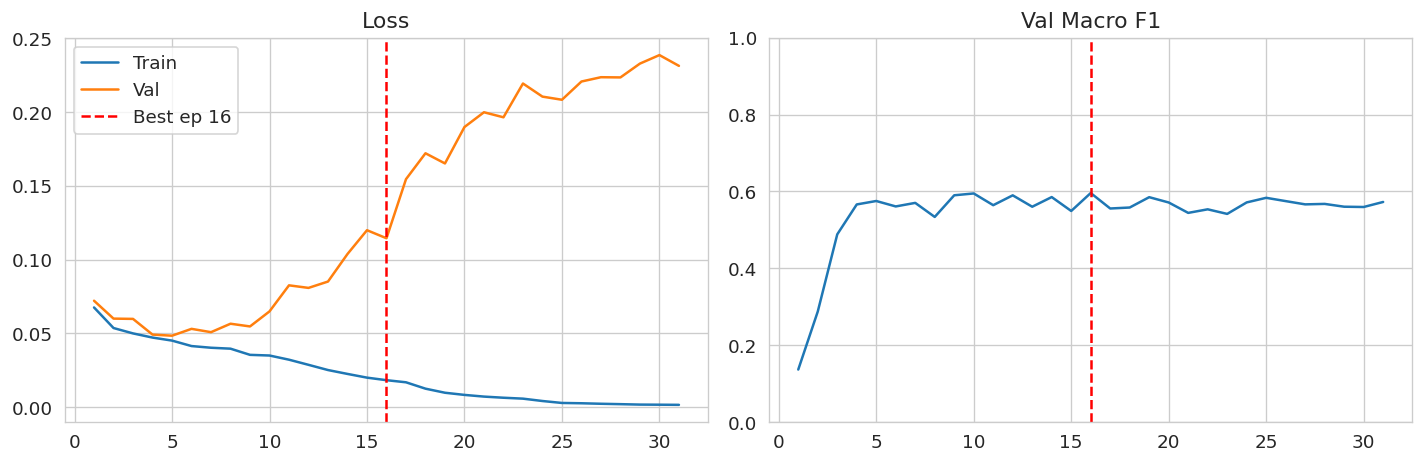

In [8]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
eps = range(1, len(train_losses)+1)
ax1.plot(eps, train_losses, label='Train'); ax1.plot(eps, val_losses, label='Val')
ax1.axvline(best_ep, color='r', ls='--', label=f'Best ep {best_ep}'); ax1.legend(); ax1.set_title('Loss')
ax2.plot(eps, val_f1s); ax2.axvline(best_ep, color='r', ls='--')
ax2.set_title('Val Macro F1'); ax2.set_ylim(0, 1)
plt.tight_layout(); plt.savefig(CKPT_DIR/'training_curves.png', dpi=100); plt.show()


## 8 . Test evaluation

In [9]:
model.load_state_dict(best_state)
_, val_probs_tune, val_tgts_tune = run_epoch(val_loader, model, criterion)
_, test_probs,     test_tgts      = run_epoch(te_loader,  model, criterion)
cv_test_probs, cv_test_targets   = val_probs_tune, val_tgts_tune
test_metrics = compute_metrics(test_probs, test_tgts)

print(f'{"Class":<6} {"Sensitivity":>12} {"Specificity":>12} {"Accuracy":>10} {"F1":>8}')
print('-'*52)
for cls in CLASS_NAMES:
    m = test_metrics[cls]
    print(f'{cls:<6} {m["sensitivity"]:>12.4f} {m["specificity"]:>12.4f} {m["accuracy"]:>10.4f} {m["f1"]:>8.4f}')
print('-'*52)
print(f'{"Macro":<6} {test_metrics["macro_sensitivity"]:>12.4f} {test_metrics["macro_specificity"]:>12.4f} '
      f'{test_metrics["macro_accuracy"]:>10.4f} {test_metrics["macro_f1"]:>8.4f}')
try: print(f'AUC macro: {roc_auc_score(test_tgts, test_probs, average="macro"):.4f}')
except: pass


Class   Sensitivity  Specificity   Accuracy       F1
----------------------------------------------------
MI           0.5079       0.9202     0.8870   0.4197
STTC         0.8028       0.6922     0.7320   0.6828
CD           0.8407       0.6267     0.7039   0.6719
HYP          0.7398       0.6129     0.6605   0.6205
----------------------------------------------------
Macro        0.7228       0.7130     0.7459   0.5987
AUC macro: 0.8078


## 9 . Threshold tuning (val set - no leakage)

In [10]:
best_thresholds = []
for i, name in enumerate(CLASS_NAMES):
    best_t, best_f = 0.5, 0.
    for t in np.arange(0.1, 0.9, 0.02):
        f = f1_score(cv_test_targets[:,i], (cv_test_probs[:,i]>=t).astype(int), zero_division=0)
        if f > best_f: best_f=f; best_t=t
    best_thresholds.append(best_t)
    print(f'  {name}: thresh={best_t:.2f}  val_F1={best_f:.4f}')
tuned_arr = np.array(best_thresholds)
test_metrics_tuned = compute_metrics(test_probs, test_tgts, tuned_arr)

preds_def   = (test_probs >= 0.5).astype(int)
preds_tuned = (test_probs >= tuned_arr).astype(int)
print(f'\n{"Class":<8} {"F1_def":>8} {"F1_tuned":>10}')
for i, name in enumerate(CLASS_NAMES):
    print(f'{name:<8} {f1_score(test_tgts[:,i],preds_def[:,i],zero_division=0):8.4f} '
          f'{f1_score(test_tgts[:,i],preds_tuned[:,i],zero_division=0):10.4f}')
f1d = f1_score(test_tgts, preds_def,   average="macro", zero_division=0)
f1t = f1_score(test_tgts, preds_tuned, average="macro", zero_division=0)
print(f'{"Macro":<8} {f1d:8.4f} {f1t:10.4f}')


  MI: thresh=0.44  val_F1=0.4367
  STTC: thresh=0.58  val_F1=0.6785
  CD: thresh=0.66  val_F1=0.6926
  HYP: thresh=0.42  val_F1=0.6111

Class      F1_def   F1_tuned
MI         0.4197     0.4112
STTC       0.6828     0.6728
CD         0.6719     0.6719
HYP        0.6205     0.6189
Macro      0.5987     0.5937


## 10 . Confusion matrices

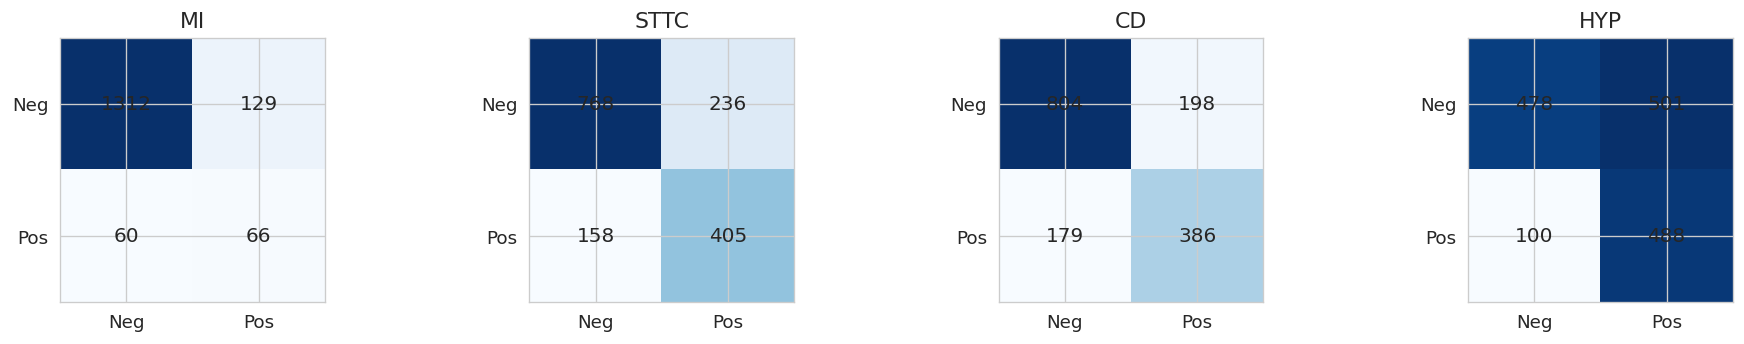

In [11]:
mcm = multilabel_confusion_matrix(test_tgts.astype(int), preds_tuned)
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for i, (ax, name) in enumerate(zip(axes, CLASS_NAMES)):
    ax.imshow(mcm[i], cmap='Blues')
    ax.set_title(name); ax.set_xticks([0,1]); ax.set_yticks([0,1])
    ax.set_xticklabels(['Neg','Pos']); ax.set_yticklabels(['Neg','Pos'])
    for r in range(2):
        for c in range(2): ax.text(c, r, mcm[i][r,c], ha='center', va='center', fontsize=12)
plt.tight_layout(); plt.savefig(CKPT_DIR/'confusion_matrices.png', dpi=100); plt.show()


## 11 . Summary

In [12]:
print('='*60)
print('  FINAL SUMMARY  |  CNN_BiLSTM_Transformer  |  Georgia')
print('='*60)
print(f'Train {len(tr_idx)} | Val {len(val_idx)} | Test {len(te_idx)}')
print(f'Best val macro-F1: {best_val_f1:.4f} @ epoch {best_ep}')
print()
for f in sorted(CKPT_DIR.iterdir()):
    if f.is_file(): print(f'  {f.name:<45} {f.stat().st_size/1024:7.1f} KB')


  FINAL SUMMARY  |  CNN_BiLSTM_Transformer  |  Georgia
Train 7229 | Val 1548 | Test 1567
Best val macro-F1: 0.5960 @ epoch 16

  best_model.pt                                  9783.9 KB
  confusion_matrices.png                           23.4 KB
  training_curves.png                              43.2 KB
